# Importing libaries

In [53]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

# Loading Data

In [54]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Data Details

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [56]:
df['Churn'].value_counts()
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [57]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
7038    False
7039    False
7040    False
7041    False
7042    False
Length: 7043, dtype: bool

In [58]:
nulls = df.isnull().sum()
ratio = 100*nulls/df.shape[0]
pd.DataFrame({'Nulls': nulls , 'Ratio': ratio}).T

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
Nulls,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [59]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [60]:
numUniq = df.nunique()
dtypes = df.dtypes
pd.DataFrame({'NumUniq' : numUniq , 'Dtypes': dtypes}).T


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
NumUniq,7043,2,2,2,2,73,2,3,3,3,...,3,3,3,3,3,2,4,1585,6531,2
Dtypes,object,object,int64,object,object,int64,object,object,object,object,...,object,object,object,object,object,object,object,float64,object,object


In [61]:
from scipy.stats import chi2_contingency
categorical_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

chi2_results = []

for col in categorical_cols:
    # Create a contingency table (Cross-tabulation)
    contingency_table = pd.crosstab(df[col], df['Churn'])
    
    # Perform Chi-Square Test
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    chi2_results.append({
        'Feature': col,
        'Chi2 Statistic': chi2,
        'p-value': p
    })

# Convert results to DataFrame and sort by importance
chi2_df = pd.DataFrame(chi2_results).sort_values(ascending=True, by='p-value')

print("--- Chi-Square Test Results ---")
print(chi2_df)

# Interpretation: Features with p-value < 0.05 are significant
significant_features = chi2_df[chi2_df['p-value'] < 0.05]['Feature'].tolist()
print(f"\nSignificant Categorical Features: {significant_features}")

--- Chi-Square Test Results ---
             Feature  Chi2 Statistic        p-value
13          Contract     1184.596572  5.863038e-258
7     OnlineSecurity      849.998968  2.661150e-185
10       TechSupport      828.197068  1.443084e-180
6    InternetService      732.309590  9.571788e-160
15     PaymentMethod      648.142327  3.682355e-140
8       OnlineBackup      601.812790  2.079759e-131
9   DeviceProtection      558.419369  5.505219e-122
12   StreamingMovies      375.661479   2.667757e-82
11       StreamingTV      374.203943   5.528994e-82
14  PaperlessBilling      258.277649   4.073355e-58
3         Dependents      189.129249   4.924922e-43
1      SeniorCitizen      159.426300   1.510067e-36
2            Partner      158.733382   2.139911e-36
5      MultipleLines       11.330441   3.464383e-03
4       PhoneService        0.915033   3.387825e-01
0             gender        0.484083   4.865787e-01

Significant Categorical Features: ['Contract', 'OnlineSecurity', 'TechSupport', 'In

# Plots 

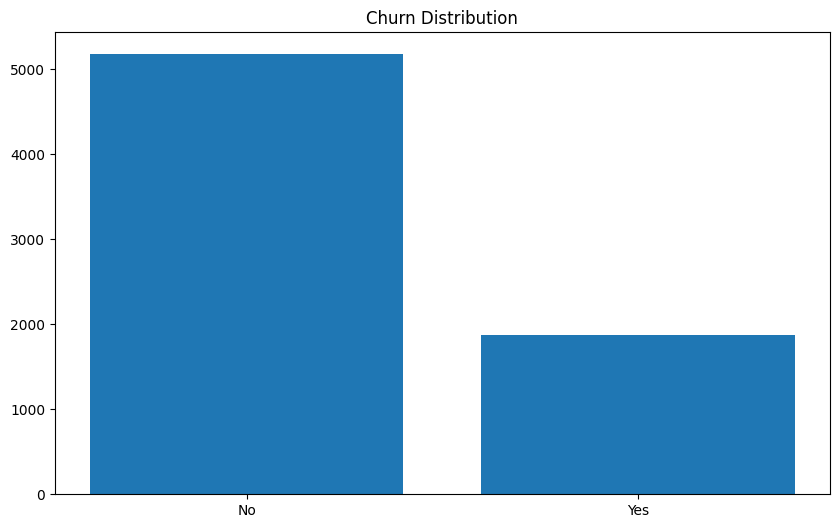

In [62]:
plt.figure(figsize=(10,6))
churn_counts = df['Churn'].value_counts()
plt.bar(churn_counts.index , churn_counts.values)
plt.title('Churn Distribution')
plt.show()

<Figure size 1000x600 with 0 Axes>

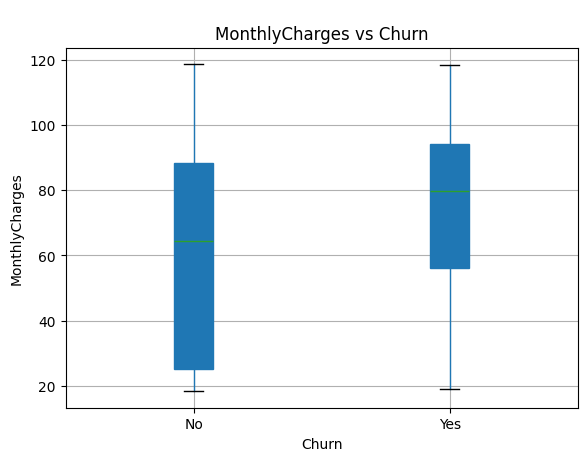

In [72]:
plt.figure(figsize=(10,6))
df.boxplot(column='MonthlyCharges' , by='Churn', vert= True , patch_artist = True)
plt.title('MonthlyCharges vs Churn')
plt.ylabel('MonthlyCharges')
plt.xlabel('Churn')
plt.suptitle(" ")
plt.show()

<Figure size 640x480 with 0 Axes>

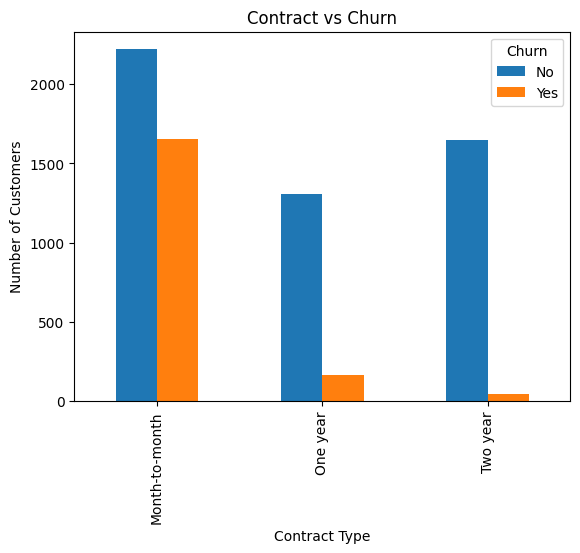

In [66]:
plt.figure()
pd.crosstab(df['Contract'], df['Churn']).plot(kind='bar')
plt.title("Contract vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.show()

# Data cleaning

In [64]:
df.drop(['customerID','gender'], axis=1 , inplace= True)

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)


C:\Users\hana\AppData\Local\Temp\ipykernel_5900\3853152841.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [65]:
categorical_cols = [
    col for col in df.columns
    if df[col].dtype == 'object' 
]
df[categorical_cols] = df[categorical_cols].astype('category')

for col in categorical_cols:
    df[col] = df[col].str.strip()

internet_cols = [
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport',
    'StreamingTV', 'StreamingMovies'
]

for col in internet_cols:
    df[col] = df[col].replace({
        'No internet service': 'No'
    })

df.to_csv('Telco_Churn.csv', index=False)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   SeniorCitizen     7043 non-null   int64  
 1   Partner           7043 non-null   object 
 2   Dependents        7043 non-null   object 
 3   tenure            7043 non-null   int64  
 4   PhoneService      7043 non-null   object 
 5   MultipleLines     7043 non-null   object 
 6   InternetService   7043 non-null   object 
 7   OnlineSecurity    7043 non-null   object 
 8   OnlineBackup      7043 non-null   object 
 9   DeviceProtection  7043 non-null   object 
 10  TechSupport       7043 non-null   object 
 11  StreamingTV       7043 non-null   object 
 12  StreamingMovies   7043 non-null   object 
 13  Contract          7043 non-null   object 
 14  PaperlessBilling  7043 non-null   object 
 15  PaymentMethod     7043 non-null   object 
 16  MonthlyCharges    7043 non-null   float64
